Contenido bajo licencia Creative Commons BY 4.0 y código bajo licencia MIT. © Manuela Bastidas Olivares y Nicolás Guarín-Zapata 2024.

# Solucion de la ecuación de Poisson usando PINNs

## Descripción del problema

Queremos resolver la siguiente ecuación

\begin{align}
\nabla^2 u(x, y)  = f(x, y)\quad \forall (x, y) \in \Omega\\
u(x, y) = 0\quad \forall (x, y) \in \partial \Omega
\end{align}

En el ejemplo tendremos $\Omega = (0, 1)^2$.


## Aproximación de la función

En este caso tenemos una aproximación

$$u_\theta(x, y) \approx \operatorname{NN}(x, y; \theta)\, ,$$

done $\operatorname{NN}$ es una red neuronal con parámetros
entrenables $\theta$.

El residual para este problema estaría dado por

$$R(x) = \nabla^2 u_\theta(x, y)  - f(x, y) \, .$$

Por el caracter no linealidad respecto a los parámetros
$\theta$ de las redes neuronales evaluar el residual
en una serie de puntos $x_i$  y forzarlo a ser cero
en estos puntos, llevaría a un sistema
no lineal de ecuaciones

$$R(x_i, y_i) = 0 \quad \forall x_i\, .$$

## Función de pérdida

Una alternativa a resolver el sistema de ecuaciones anteriormente
planteado es minimizar

$$\min_\theta \frac{1}{N}\sum_{i}^N |R(x_i, y_i)|^2 \, .$$

Que sería exactamente 0 si cada uno de los residuales es igual a 0.

A este problema le harían falta las condiciones de frontera. Para
esto se propone una función objetivo que las incluya

$$\min_\theta \lambda_2\frac{1}{N}\sum_{i}^N R(x_i, y_i)^2
+ \lambda_2 \frac{1}{M}\sum_{\substack{i\\ (x_i, y_i) \in \partial\Omega}}^M u_\theta(x_i, y_i)^2\, .$$

## Ejemplo computacional

In [ ]:
!sudo apt-get update
!sudo apt-get install texlive-latex-extra texlive-fonts-recommended dvipng cm-super ghostscript

import time
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.stats import qmc
from torch.autograd import grad




plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "mathtext.fontset": "cm",
    "font.size": 16,

    # Ejes y Ticks
    "axes.labelsize": 16,
    "axes.titlesize": 18,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "xtick.direction": "in",
    "ytick.direction": "in",

    # Grid                          # ← bug 1: sintaxis mezclada
    "grid.color"    : "gray",       # todo debe ir como claves del dict
    "grid.linewidth": 0.3,
    "grid.alpha"    : 0.3,
    "grid.linestyle": "--",

    # Estética
    "figure.dpi"        : 120,
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "savefig.bbox"      : "tight",
    "savefig.dpi"       : 300,
})

print('Configuración OK')

Hit:1 https://cli.github.com/packages stable InRelease
Hit:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:3 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:4 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
cm-super is already the newest version (0.3.4-17).
dvipng is already the newest version (1.15-

## Puntos de muestreo

Para entrenar la PINN, generaremos el dominio utilizando la estrategia de muestreo `LatinHypercube` (LHS). LHS asegura que las muestras cubran uniformemente el espacio de entrada, garantizando que las muestras no estén agrupadas en un área pequeña, sino que estén distribuidas en todo el espacio.

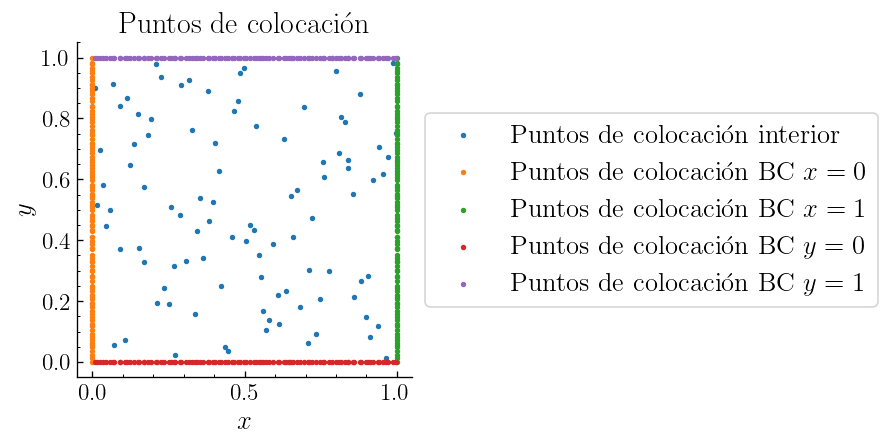

In [ ]:
# Definimos el número de muestras (puntos) que queremos generar para nuestro dominio
dom_samples = 100

# Crea un arreglo de 100 valores espaciados uniformemente entre 0 y 1 para la coordenada horizontal (x)
x = np.linspace(0, 1, dom_samples)

# Crea un arreglo de 100 valores espaciados uniformemente entre 0 y 1 para la coordenada vertical (y)
y = np.linspace(0, 1, dom_samples)

# Genera una cuadrícula bidimensional (X, Y) a partir de los arreglos unidimensionales definidos arriba
X, Y = np.meshgrid(x, y)

# Inicializa el muestreador basado en la estrategia Latin Hypercube Sampling (LHS) para 2 dimensiones (d=2)
# Esta estrategia asegura que las muestras cubran uniformemente el espacio de entrada, garantizando que las muestras no estén agrupadas en un área pequeña, sino que estén distribuidas en todo el espacio[cite: 1].
sampler = qmc.LatinHypercube(d=2)

# Genera las muestras aleatorias basándose en el número definido al inicio (n=100)
sample = sampler.random(n=dom_samples)

# Establece el límite inferior del dominio para x e y (ambos arrancan en 0)
l_bounds = [ 0, 0]

# Establece el límite superior del dominio para x e y (ambos terminan en 1)
u_bounds = [ 1, 1]

# Escala las muestras generadas por LHS (que por defecto van de 0 a 1) para que se ajusten estrictamente a nuestros límites inferior y superior definidos
domain_xt = qmc.scale(sample, l_bounds, u_bounds)

# Extrae la primera columna de las muestras (coordenada x) y la convierte en un tensor de PyTorch de tipo flotante
# El parámetro "requires_grad = True" indica a PyTorch que calcule los gradientes sobre este tensor, y "reshape(-1,1)" le da formato de vector columna
x_ten = torch.tensor(domain_xt[:, 0], requires_grad = True).float().reshape(-1,1)

# Extrae la segunda columna de las muestras (coordenada y) y la convierte en un tensor de PyTorch con las mismas propiedades del paso anterior
y_ten = torch.tensor(domain_xt[:, 1], requires_grad = True).float().reshape(-1,1)

# Crea una nueva figura y sus ejes en Matplotlib, con un tamaño específico de 8x4 pulgadas
fig, ax = plt.subplots(figsize=(8, 4))

# Grafica un diagrama de dispersión con las coordenadas interiores del dominio, asignando un tamaño de punto pequeño (s=5) y una etiqueta
ax.scatter(domain_xt[:, 0], domain_xt[:, 1], s=5,
           label='Puntos de colocación interior')

# Dibuja los puntos correspondientes a la condición de frontera (BC) donde x=0
# Usa un arreglo de ceros para el eje x, y los valores extraídos del tensor 'y' (sin seguimiento de gradiente gracias a "detach()") para el eje y
ax.scatter(np.zeros_like(y_ten.detach().numpy()), y_ten.detach().numpy(),
           s=5, label=r'Puntos de colocación BC $x=0$')

# Dibuja los puntos correspondientes a la condición de frontera donde x=1
# Usa un arreglo de unos (np.ones_like) para el eje x, y los valores del tensor 'y' para el eje y
ax.scatter(np.ones_like(y_ten.detach().numpy()), y_ten.detach().numpy(),
           s=5, label=r'Puntos de colocación BC $x=1$')

# Dibuja los puntos correspondientes a la condición de frontera donde y=0
# Usa los valores del tensor 'x' para el eje x, y un arreglo de ceros para el eje y
ax.scatter(x_ten.detach().numpy(), np.zeros_like(x_ten.detach().numpy()),
           s=5, label=r'Puntos de colocación BC $y=0$')

# Dibuja los puntos correspondientes a la condición de frontera donde y=1
# Usa los valores del tensor 'x' para el eje x, y un arreglo de unos para el eje y
ax.scatter(x_ten.detach().numpy(), np.ones_like(x_ten.detach().numpy()),
           s=5, label=r'Puntos de colocación BC $y=1$')

ax.set_title('Puntos de colocación')
ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$y$')
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.axis("image")
plt.tight_layout()
plt.show()

### Solución analítica
Definimos la solución analítica $u(x, y) = 16\, x\, y\, (1 - x) \, (1 - y)$
para el problema de la ecuación de Poisson.



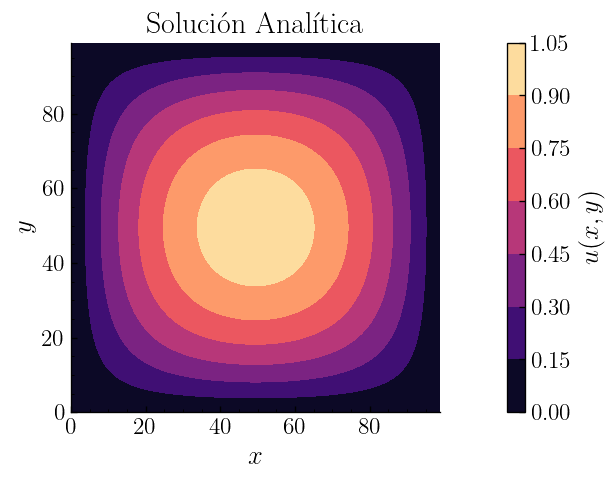

In [ ]:
def u_analytic(x, y):
    return 16*(1 - x) * x * (1 - y) * y # Aquí evaluamos puntos de la solución analítica

# Mostrar la solución exacta u(x, y)
plt.figure(figsize=(6, 4))
plt.title("Solución Analítica")
img = plt.contourf(u_analytic(X, Y), cmap='magma')
plt.colorbar(img, label='$u(x,y)$')
plt.xlabel(r'$x$')
plt.ylabel(r'$y$')
plt.axis("image")
plt.grid(False)

# Definición de red neuronal

Ahora, utilizamos `PyTorch` y definimos la red neuronal y, para esta tarea, utilizaremos el optimizador `ADAM`.

In [ ]:
# --- Parámetros de entrenamiento ---

# Define la arquitectura de la red en forma de lista:
# 2 neuronas de entrada, 3 capas ocultas de 10 neuronas cada una, y 1 neurona de salida
hidden_layers = [2, 10, 10, 10, 1]
learning_rate = 0.001

# Establece el número total de iteraciones
training_iter = 20000

# Define la función de pérdida utilizando el Error Cuadrático Medio
MSE_func = nn.MSELoss()


# Define una clase de red neuronal que hereda de 'nn.Module',
# que es la clase base para todos los modelos de redes neuronales en PyTorch
class NeuralNetwork(nn.Module):

    # Método constructor de la clase, recibe como argumento la lista de capas (hlayers)
    def __init__(self, hlayers):
        # Llama al constructor de la clase padre (nn.Module) para inicializar correctamente el módulo
        super(NeuralNetwork, self).__init__()

        # Inicializa una lista vacía donde iremos guardando secuencialmente las capas de nuestra red
        layers = []

        # Inicia un ciclo que recorre la lista de capas, excluyendo las dos últimas posiciones
        # Esto se hace para aplicar la función de activación solo en las capas ocultas, no en la salida
        for i in range(len(hlayers[:-2])):
            # Añade a la lista una capa lineal (completamente conectada)
            # Toma entradas del tamaño de la capa actual y genera salidas del tamaño de la siguiente capa
            layers.append(nn.Linear(hlayers[i], hlayers[i+1]))

            # Añade una función de activación Tangente Hiperbólica (Tanh) después de la capa lineal
            # Esto introduce no-linealidad, permitiendo a la red aprender patrones complejos
            layers.append(nn.Tanh())

        # Añade la última capa lineal (la capa de salida) que conecta la penúltima capa con la última.
        layers.append(nn.Linear(hlayers[-2], hlayers[-1]))

        # Empaqueta toda la lista de capas en un contenedor secuencial (nn.Sequential)
        # Esto permite que los datos fluyan automáticamente a través de las capas en el orden definido
        self.layers = nn.Sequential(*layers)

        # Llama al método para inicializar los pesos de la red.
        self.init_params

    # Método encargado de definir la inicialización de los parámetros (pesos) de la red
    def init_params(self):
        """Xavier Glorot parameter initialization of the Neural Network
        """
        # Define una función interna que evaluará cada capa (módulo) individual
        def init_normal(m):
            # Comprueba si la capa actual es una capa lineal (ya que las funciones de activación no tienen pesos)
            if isinstance(m, nn.Linear):
                # Si es lineal, inicializa sus pesos usando la distribución normal de Xavier/Glorot
                # Este tipo de inicialización es muy recomendada para redes que usan activación Tanh
                nn.init.xavier_normal_(m.weight) # Xavier

        # Aplica la función 'init_normal' recursivamente a todas las subcapas que componen nuestro modelo
        self.apply(init_normal)

    # El método 'forward' es obligatorio en PyTorch. Define cómo pasan los datos hacia adelante en la red.
    def forward(self, x):
        # Toma los datos de entrada 'x', los pasa a través de nuestro contenedor secuencial de capas,
        # y retorna el resultado final (la predicción)
        return self.layers(x)

In [ ]:
# Crear una instancia de la red neuronal
u_pinn = NeuralNetwork(hidden_layers)
nparams = sum(p.numel() for p in u_pinn.parameters() if p.requires_grad)
print(f'Número de parámetros entrenables: {nparams}')

# Definir un optimizador (Adam) para entrenar la red
optimizer = torch.optim.Adam(u_pinn.parameters(), lr=0.001,
                       betas= (0.9,0.999), eps = 1e-8)

Número de parámetros entrenables: 261


### Función de Pérdida Informada por la Física

In [ ]:
# Definición de la función gradiente que calcula la derivada parcial de una salida con respecto a una entrada
def grad(outputs, inputs):
    # Utiliza la diferenciación automática de PyTorch (autograd) para calcular la derivada
    return torch.autograd.grad(outputs, inputs,
                        # Especifica un tensor de unos del mismo tamaño que 'outputs' para calcular el Jacobiano
                        grad_outputs=torch.ones_like(outputs),
                        # 'create_graph=True' es crucial aquí: permite calcular derivadas de orden superior (como la segunda derivada)
                        create_graph=True,
                        # 'retain_graph=True' mantiene el grafo computacional en memoria para múltiples llamadas a backward/grad
                        retain_graph=True)[0]

# Definición de la función de pérdida para la Red Neuronal Informada por la Física (PINN)
# Recibe el modelo (forward_pass), los tensores espaciales (x_ten, y_ten) y pesos (lambdas) para equilibrar las pérdidas
def PINN_poisson_Loss(forward_pass, x_ten, y_ten,
             lambda1 = 1, lambda2 = 1, lambda3 = 1, lambda4 = 1):

    # --- Salida de la red neuronal y cálculo de derivadas ---

    # Concatena los tensores columna de x e y horizontalmente (dim=1) para crear las coordenadas de entrada (x, y)
    domain = torch.cat([x_ten, y_ten], dim = 1)

    # Pasa las coordenadas por la red neuronal para obtener la predicción del modelo: $u(x,y)$
    u = forward_pass(domain)

    # Calcula la primera derivada parcial de u con respecto a x: $\frac{\partial u}{\partial x}$
    u_x = grad(u, x_ten)

    # Calcula la segunda derivada parcial de u con respecto a x: $\frac{\partial^2 u}{\partial x^2}$
    u_xx = grad(u_x, x_ten)

    # Calcula la primera derivada parcial de u con respecto a y: $\frac{\partial u}{\partial y}$
    u_y = grad(u, y_ten)

    # Calcula la segunda derivada parcial de u con respecto a y: $\frac{\partial^2 u}{\partial y^2}$
    u_yy = grad(u_y, y_ten)

    # --- Definición de la pérdida de la Ecuación Diferencial Parcial (PDE) ---

    # Define el residuo de la ecuación de Poisson.
    # La PDE es: $u_{xx} + u_{yy} + 32(y(1-y) + x(1-x)) = 0$
    # Si la red ha aprendido perfectamente, f_pde debería ser cero en todos los puntos.
    f_pde = u_xx + u_yy +  32*((1 - y_ten)*y_ten + (1 - x_ten)*x_ten)

    # Calcula el Error Cuadrático Medio (MSE) entre el residuo f_pde y un tensor de puros ceros.
    # Multiplica por el peso lambda1.
    PDE_loss = lambda1 * MSE_func(f_pde, torch.zeros_like(f_pde))

    # --- Definición de las condiciones de contorno (BC) y sus pérdidas ---

    # Condición de frontera inferior ($y=0$): Concatena los valores de 'x' con ceros en lugar de 'y'
    bcy1 = torch.cat([x_ten,torch.zeros_like(y_ten)], dim = 1)
    # Evalúa la red en esta frontera
    g_bcy1 = forward_pass(bcy1)
    # Calcula el MSE asumiendo que en esta frontera el valor real debe ser 0 (condición de Dirichlet homogénea)
    bcy1_loss = lambda1 * MSE_func(g_bcy1, torch.zeros_like(g_bcy1))

    # Condición de frontera superior ($y=1$): Concatena los valores de 'x' con unos en lugar de 'y'
    bcy2 = torch.cat([x_ten, torch.ones_like(y_ten)], dim = 1)
    # Evalúa la red en esta frontera
    g_bcy2 = forward_pass(bcy2)
    # Calcula el error respecto a 0, ponderado por lambda2
    bcy2_loss = lambda2 * MSE_func(g_bcy2, torch.zeros_like(g_bcy2))

    # Condición de frontera izquierda ($x=0$): Concatena ceros en lugar de 'x' con los valores de 'y'
    bcx1 = torch.cat([torch.zeros_like(x_ten), y_ten], dim = 1)
    # Evalúa la red en esta frontera
    g_bcx1 = forward_pass(bcx1)
    # Calcula el error respecto a 0, ponderado por lambda3
    bcx1_loss = lambda3 * MSE_func(g_bcx1, torch.zeros_like(g_bcx1))

    # Condición de frontera derecha ($x=1$): Concatena unos en lugar de 'x' con los valores de 'y'
    bcx2 = torch.cat([torch.ones_like(x_ten), y_ten], dim = 1)
    # Evalúa la red en esta frontera
    g_bcx2 = forward_pass(bcx2)
    # Calcula el error respecto a 0, ponderado por lambda4
    bcx2_loss = lambda4 * MSE_func(g_bcx2, torch.zeros_like(g_bcx2))

    # --- Retorno ---

    # La función de pérdida total es la suma de la penalización por no cumplir la ecuación (física)
    # y las penalizaciones por no cumplir las condiciones en cada uno de los cuatro bordes del dominio
    return PDE_loss + bcx1_loss + bcx2_loss + bcy1_loss + bcy2_loss

## Entrenamiento del modelo

In [ ]:
# Inicialización de una lista vacía para almacenar los valores de pérdida (error) en cada época.
# Esto es muy útil para graficar la curva de aprendizaje más adelante y verificar que la red convergió.
loss_values = []

# Inicio del temporizador usando la librería 'time'
# Guarda la marca de tiempo actual antes de que comience el ciclo para medir el rendimiento.
start_time = time.time()

# Inicia el bucle de entrenamiento de la red neuronal.
# Se ejecutará tantas veces como se haya definido en la variable 'training_iter' (ej. 20,000 veces).
for i in range(training_iter):

    # Limpieza de los gradientes para el próximo entrenamiento.
    # En PyTorch, los gradientes se acumulan por defecto, por lo que es obligatorio reiniciarlos a cero
    optimizer.zero_grad()

    # Calcula la pérdida actual evaluando la función 'PINN_poisson_Loss'.
    # Se le pasa la red neuronal (u_pinn) y los puntos de colocación del dominio (x_ten, y_ten).
    # Esta función calcula qué tan lejos está la red de cumplir la física y las condiciones de contorno.
    loss = PINN_poisson_Loss(u_pinn, x_ten, y_ten)

    # Añade el valor actual de la pérdida a la lista que creamos al inicio.
    # 'loss.item()' extrae el valor numérico estándar de Python a partir del tensor de un solo elemento de PyTorch.
    loss_values.append(loss.item())

    # Condicional para imprimir el progreso del entrenamiento en consola.
    # El operador módulo (%) verifica si la iteración actual es un múltiplo de 1000.
    if i % 1000 == 0:
        print(f"Iteración {i}: Pérdida {loss.item()}")

    # Calcula los gradientes de la pérdida con respecto a todos los parámetros (pesos y sesgos) de la red. Esto se conoce como retropropagación (backpropagation).
    loss.backward()

    # Actualiza los pesos de la red neuronal.
    # El optimizador (por ejemplo, Adam o SGD) toma los gradientes recién calculados y ajusta los parámetros
    # del modelo para intentar que el valor de 'loss' sea menor en la próxima iteración.
    optimizer.step()

# Parar el temporizador tomando una nueva marca de tiempo justo al salir del bucle de entrenamiento.
end_time = time.time()

# Calcula el tiempo total transcurrido restando el tiempo de inicio al tiempo de finalización.
elapsed_time = end_time - start_time
print(f"Tiempo de entrenamiento: {elapsed_time} segundos")

Iteración 0: Pérdida 126.26329803466797
Iteración 1000: Pérdida 0.3563297688961029
Iteración 2000: Pérdida 0.19882437586784363
Iteración 3000: Pérdida 0.17993132770061493
Iteración 4000: Pérdida 0.16689564287662506
Iteración 5000: Pérdida 0.14533157646656036
Iteración 6000: Pérdida 0.11019538342952728
Iteración 7000: Pérdida 0.07671432197093964
Iteración 8000: Pérdida 0.04609597474336624
Iteración 9000: Pérdida 0.028501152992248535
Iteración 10000: Pérdida 0.018406199291348457
Iteración 11000: Pérdida 0.014240216463804245
Iteración 12000: Pérdida 0.009160896763205528
Iteración 13000: Pérdida 0.006526358425617218
Iteración 14000: Pérdida 0.004817548207938671
Iteración 15000: Pérdida 0.003698294283822179
Iteración 16000: Pérdida 0.0029246327467262745
Iteración 17000: Pérdida 0.0024054842069745064
Iteración 18000: Pérdida 0.002626002999022603
Iteración 19000: Pérdida 0.0017700089374557137
Tiempo de entrenamiento: 130.43052411079407 segundos


## Predicción

In [ ]:
# Convertir los datos X e Y a tensores de PyTorch y cambiar su forma
X_ten = torch.tensor(X).float().reshape(-1, 1)
Y_ten = torch.tensor(Y).float().reshape(-1, 1)

# Concatenar los tensores X e Y en un solo tensor
domain_ten = torch.cat([X_ten,Y_ten], dim = 1)

# Generar predicciones usando la red neuronal y cambiar la forma para que coincida con la cuadrícula
U_pred = u_pinn(domain_ten).detach().numpy().reshape(X.shape)

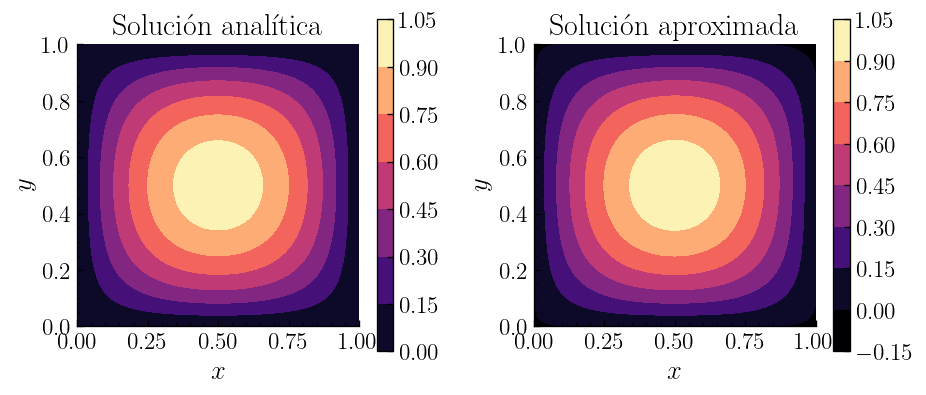

In [ ]:
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.contourf(X, Y, u_analytic(X, Y), cmap='magma',
            vmin=0, vmax=1)
plt.colorbar(shrink=0.8)
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.title("Solución analítica")
plt.axis("image")
plt.grid(False)

plt.subplot(1, 2, 2)
plt.contourf(X, Y, U_pred, cmap='magma',
            vmin=0, vmax=1)
plt.colorbar(shrink=0.8)
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.title("Solución aproximada")
plt.axis("image")
plt.grid(False)

plt.tight_layout()

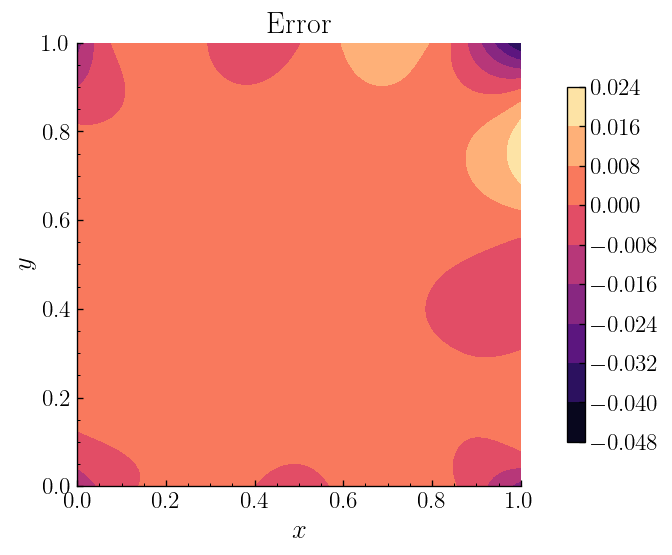

In [ ]:
plt.figure()
plt.contourf(X, Y, U_pred - u_analytic(X, Y), cmap='magma')
plt.colorbar(shrink=0.8)
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.title("Error")
plt.axis("image")
plt.grid(False)